In [1]:
# Import modules / library
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np
import os

In [3]:
# Membaca file csv
df_mutations = pd.read_csv('./content/mutations.csv')
df_accounts = pd.read_csv('./content/accounts.csv')
df_users = pd.read_csv('./content/users.csv')

In [5]:
# Menambahkan header pada file dan membaca file
new_headers_mutations = ['id', 'account_id', 'mutation_type', 'amount','description','reference_code','created_at']
df_mutations = pd.read_csv('./content/mutations.csv', header=None, names=new_headers_mutations)

# Melihat 5 file teratas
df_mutations.head()

,id,account_id,mutation_type,amount,description,reference_code,created_at
0,1,1,credit,500000.0,Gaji Bulanan,TXN001,2025-06-16 07:51:47.214055
1,2,1,debit,150000.0,Pembayaran listrik,TXN002,2025-06-16 07:51:47.214055
2,3,2,credit,750000.0,Komisi Proyek,TXN003,2025-06-16 07:51:47.214055
3,4,2,debit,200000.0,Belanja Online,TXN004,2025-06-16 07:51:47.214055
4,5,3,credit,1200000.0,Transfer dari HRD,TXN005,2025-06-16 07:51:47.214055


In [6]:
# Mendapatkan Informasi dari data
df_mutations.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 50040 entries, 0 to 50039
Data columns (total 7 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   id              50040 non-null  int64  
 1   account_id      50040 non-null  int64  
 2   mutation_type   50040 non-null  object 
 3   amount          50040 non-null  float64
 4   description     50040 non-null  object 
 5   reference_code  50040 non-null  object 
 6   created_at      50040 non-null  object 
dtypes: float64(1), int64(2), object(4)
memory usage: 2.7+ MB


In [7]:
# Mendapatkan informasi statistik
df_mutations.describe()

,id,account_id,amount
count,50040.000000,50040.000000,5.004000e+04
mean,25020.500000,5039.112210,8.438008e+02
std,14445.448072,2905.011158,1.471653e+04
min,1.000000,1.000000,2.000000e-02
25%,12510.750000,2519.000000,2.509825e+02
50%,25020.500000,5041.000000,5.012100e+02
75%,37530.250000,7577.000000,7.517900e+02
max,50040.000000,10040.000000,1.200000e+06


In [8]:
# Melihat lebih detail pada waktu atau tanggal

# Konversi kolom 'created_at' ke tipe datetime
df_mutations['created_at'] = pd.to_datetime(df_mutations['created_at'])

print("Informasi DataFrame setelah konversi 'created_at':")
df_mutations.info()
print("\n")

# Ekstrak komponen tanggal dan waktu untuk analisis lebih lanjut
df_mutations['transaction_date'] = df_mutations['created_at'].dt.date
df_mutations['transaction_hour'] = df_mutations['created_at'].dt.hour
df_mutations['transaction_month'] = df_mutations['created_at'].dt.month
df_mutations['transaction_year'] = df_mutations['created_at'].dt.year

print("DataFrame dengan kolom tanggal tambahan:")
print(df_mutations.head())
print("\n")

Informasi DataFrame setelah konversi 'created_at':
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 50040 entries, 0 to 50039
Data columns (total 7 columns):
 #   Column          Non-Null Count  Dtype         
---  ------          --------------  -----         
 0   id              50040 non-null  int64         
 1   account_id      50040 non-null  int64         
 2   mutation_type   50040 non-null  object        
 3   amount          50040 non-null  float64       
 4   description     50040 non-null  object        
 5   reference_code  50040 non-null  object        
 6   created_at      50040 non-null  datetime64[ns]
dtypes: datetime64[ns](1), float64(1), int64(2), object(3)
memory usage: 2.7+ MB


DataFrame dengan kolom tanggal tambahan:
   id  account_id mutation_type     amount         description reference_code  \
0   1           1        credit   500000.0        Gaji Bulanan         TXN001   
1   2           1         debit   150000.0  Pembayaran listrik         TXN002   
2   3 

Total Mutasi per Tipe:
mutation_type
credit    25104
debit     24936
Name: count, dtype: int64


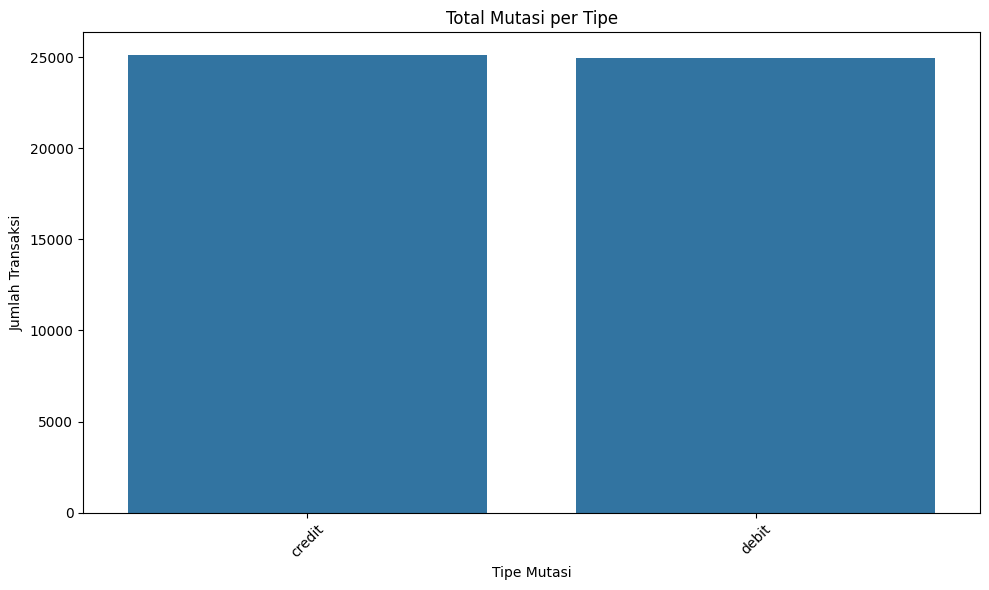



Total Jumlah (Amount) per Tipe Mutasi:
mutation_type
credit    25439075.84
debit     16784715.50
Name: amount, dtype: float64


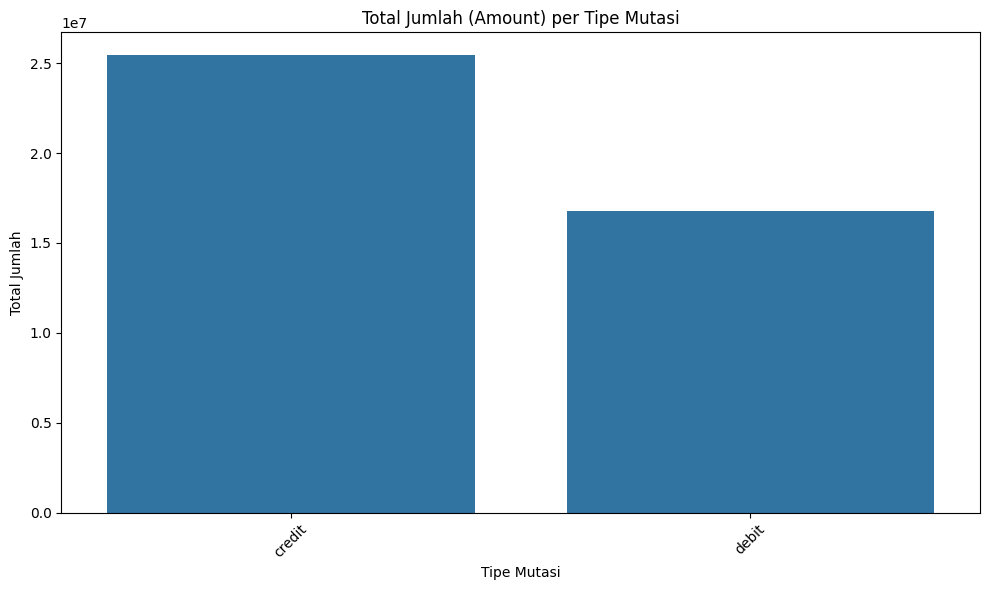



Rata-rata Jumlah (Amount) per Tipe Mutasi:
mutation_type
credit    1013.347508
debit      673.111786
Name: amount, dtype: float64


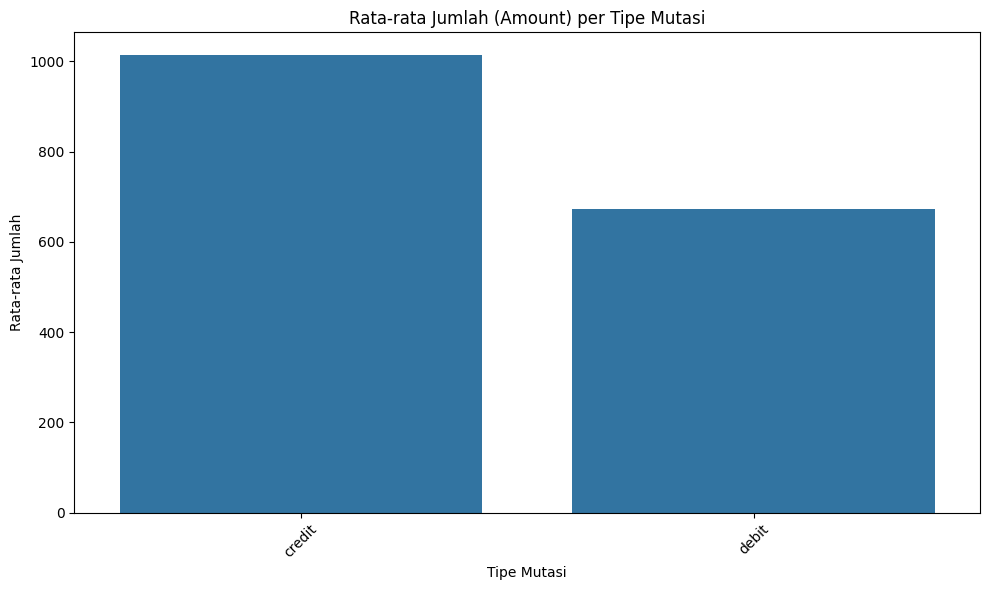

In [9]:
# Grafik Mutasi

# Total mutasi per tipe
total_mutations_by_type = df_mutations['mutation_type'].value_counts()
print("Total Mutasi per Tipe:")
print(total_mutations_by_type)
plt.figure(figsize=(10, 6))
sns.barplot(x=total_mutations_by_type.index, y=total_mutations_by_type.values)
plt.title('Total Mutasi per Tipe')
plt.xlabel('Tipe Mutasi')
plt.ylabel('Jumlah Transaksi')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()
print("\n")

# Total amount per tipe mutasi
total_amount_by_type = df_mutations.groupby('mutation_type')['amount'].sum().sort_values(ascending=False)
print("Total Jumlah (Amount) per Tipe Mutasi:")
print(total_amount_by_type)
plt.figure(figsize=(10, 6))
sns.barplot(x=total_amount_by_type.index, y=total_amount_by_type.values)
plt.title('Total Jumlah (Amount) per Tipe Mutasi')
plt.xlabel('Tipe Mutasi')
plt.ylabel('Total Jumlah')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()
print("\n")

# Rata-rata amount per tipe mutasi
avg_amount_by_type = df_mutations.groupby('mutation_type')['amount'].mean().sort_values(ascending=False)
print("Rata-rata Jumlah (Amount) per Tipe Mutasi:")
print(avg_amount_by_type)
plt.figure(figsize=(10, 6))
sns.barplot(x=avg_amount_by_type.index, y=avg_amount_by_type.values)
plt.title('Rata-rata Jumlah (Amount) per Tipe Mutasi')
plt.xlabel('Tipe Mutasi')
plt.ylabel('Rata-rata Jumlah')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()
print("\n")